# Statistical Feature Selection for TNBC Classification

This notebook applies statistical methods to select the most promising genes (features) for classifying triple negative breast cancer (TNBC) using RNA sequencing data

By combining techniques such as variance filtering, correlation analysis, t-tests, and mutual information, we identify a robust and interpretable set of genes to serve as input for machine learning models in the next project phase. This approach supports transparency, reproducibility, and biological relevance for the final classification model.

In [1]:
# Statistical Feature Selection for TNBC Classification
# This notebook identifies genes that best distinguish TNBC from non-TNBC samples
# using multiple statistical techniques (correlation, t-tests, mutual information)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')  # Hide sklearn warnings for cleaner output
%run "../Model/DataHelpers.ipynb"

In [2]:
# Configure plot styling for better visualization
plt.style.use('default')
sns.set_palette('husl')

# This variant identifier helps us keep track of different feature selection approaches
variant = 'statistical'
print(f"Starting statistical feature selection for variant: {variant}")

print(f'Loading gene data - Start')
# Load preprocessed patient x gene matrix
df = pd.read_csv('../Data/geneDataPreProcessed.csv')
print(f'Loading gene data - End')

Starting statistical feature selection for variant: statistical
Loading gene data - Start
Loading gene data - End


### Dataset split: training and test data

In [3]:
X, y, X_train, X_test, y_train, y_test, test_case_ids = split_data(df, "tnbc", True)

X_train.shape=(781, 19938)
X_test.shape=(196, 19938)
y_train.shape=(781,)
y_test.shape=(196,)


### Feature scaling
Feature scaling is applied for consistency with other feature-selection methods
and to support scale-sensitive statistics (e.g. mutual information).
Some statistics (e.g. correlation, t-tests) are scale-invariant.

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

print(f'Apply Scaling - Start')
X_trainScaled = scaler.fit_transform(X_train)
X_testScaled  = scaler.transform(X_test) 
X_trainScaled_df = pd.DataFrame(
    X_trainScaled,
    columns=X_train.columns,
    index=X_train.index
)
print(f'Apply Scaling - End')

Apply Scaling - Start
Apply Scaling - End


## Pearson

Correlation Analysis with TNBC Status

Top 20 genes by absolute correlation with TNBC:
          gene  correlation  abs_correlation        p_value
6074     FOXA1    -0.662618         0.662618  6.859343e-100
4430      MLPH    -0.656959         0.656959   1.194319e-97
1931      ESR1    -0.648239         0.648239   2.732412e-94
13254     AGR3    -0.634670         0.634670   2.816180e-89
7781      TTC6    -0.627547         0.627547   9.597584e-87
17048     CT83     0.625750         0.625750   4.080736e-86
3297      AGR2    -0.617849         0.617849   2.119130e-83
10275     TFF3    -0.613909         0.613909   4.484122e-82
15976     FZD9     0.597990         0.597990   6.615565e-77
10277     TFF1    -0.595890         0.595890   3.026735e-76
3392     GATA3    -0.592422         0.592422   3.640812e-75
17138  SLC44A4    -0.590596         0.590596   1.332318e-74
5504     SPDEF    -0.588119         0.588119   7.639618e-74
13759    PRR15    -0.587540         0.587540   1.146309e-73
14977    SRAR

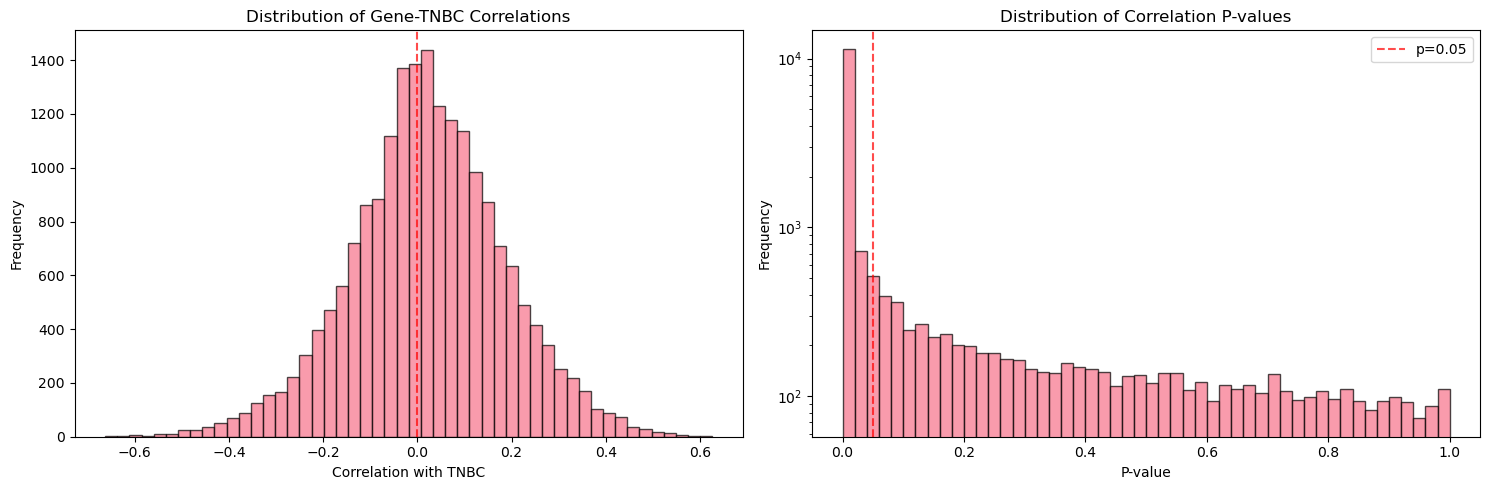


Genes with significant correlation (p<0.05, |r|>0.1): 10055
Top 10:
        gene  correlation  abs_correlation        p_value
6074   FOXA1    -0.662618         0.662618  6.859343e-100
4430    MLPH    -0.656959         0.656959   1.194319e-97
1931    ESR1    -0.648239         0.648239   2.732412e-94
13254   AGR3    -0.634670         0.634670   2.816180e-89
7781    TTC6    -0.627547         0.627547   9.597584e-87
17048   CT83     0.625750         0.625750   4.080736e-86
3297    AGR2    -0.617849         0.617849   2.119130e-83
10275   TFF3    -0.613909         0.613909   4.484122e-82
15976   FZD9     0.597990         0.597990   6.615565e-77
10277   TFF1    -0.595890         0.595890   3.026735e-76


In [5]:
# Correlation Analysis with TNBC Status (training data only)
# Pearson correlation is scale-invariant.
# Scaled training features are used here for consistency with other
# feature-selection methods and to maintain a single feature representation.
print("Correlation Analysis with TNBC Status")
print("=" * 50)
correlations = []
for gene in X_trainScaled_df.columns:
    try:
        corr_coef, p_value = stats.pearsonr(X_trainScaled_df[gene],y_train)
        correlations.append({
            'gene': gene,
            'correlation': corr_coef,
            'abs_correlation': abs(corr_coef),
            'p_value': p_value
        })
    except Exception as e:
        print(f"Error calculating correlation for {gene}: {e}")

# Convert to DataFrame and sort by absolute correlation
corr_df = pd.DataFrame(correlations)
corr_df = corr_df.sort_values('abs_correlation', ascending=False)

print(f"\nTop 20 genes by absolute correlation with TNBC:")
print(corr_df.head(20))

# Visualize correlation distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Correlation distribution
ax1.hist(corr_df['correlation'], bins=50, alpha=0.7, edgecolor='black')
ax1.axvline(x=0, color='red', linestyle='--', alpha=0.7)
ax1.set_xlabel('Correlation with TNBC')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Gene-TNBC Correlations')

# P-value distribution
ax2.hist(corr_df['p_value'], bins=50, alpha=0.7, edgecolor='black')
ax2.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, label='p=0.05')
ax2.set_xlabel('P-value')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Correlation P-values')
ax2.legend()
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

# Filter genes with significant correlations
significant_corr_genes = corr_df[(corr_df['p_value'] < 0.05) & (corr_df['abs_correlation'] > 0.1)]
print(f"\nGenes with significant correlation (p<0.05, |r|>0.1): {len(significant_corr_genes)}")
print("Top 10:")
print(significant_corr_genes.head(10))

Statistical T-tests for Group Differences
TNBC group size (train): 92
Non-TNBC group size (train): 689

Top 20 genes by t-test significance and effect size:
           gene  t_statistic       p_value  cohens_d  abs_cohens_d  tnbc_mean  \
13228      CST9   -20.299044  6.696337e-57 -1.209218      1.209218  -0.995035   
11515  C10orf82   -21.053529  1.744788e-56 -1.328018      1.328018  -1.078199   
2506      CST9L   -17.142796  1.990797e-55 -0.781978      0.781978  -0.669743   
12807      NAT1   -22.509054  2.068612e-55 -1.592530      1.592530  -1.251118   
16342     POTEI   -20.223498  8.889373e-53 -1.304802      1.304802  -1.062211   
1931       ESR1   -25.958910  6.584758e-52 -2.637494      2.637494  -1.773987   
5251     SPINK4   -18.301700  1.683480e-50 -1.070217      1.070217  -0.893546   
3632     TBC1D9   -23.084905  1.711653e-50 -1.965138      1.965138  -1.465851   
14341    GPR139   -17.338894  3.090578e-50 -0.933138      0.933138  -0.789248   
14977     SRARP   -24.054338  3.3

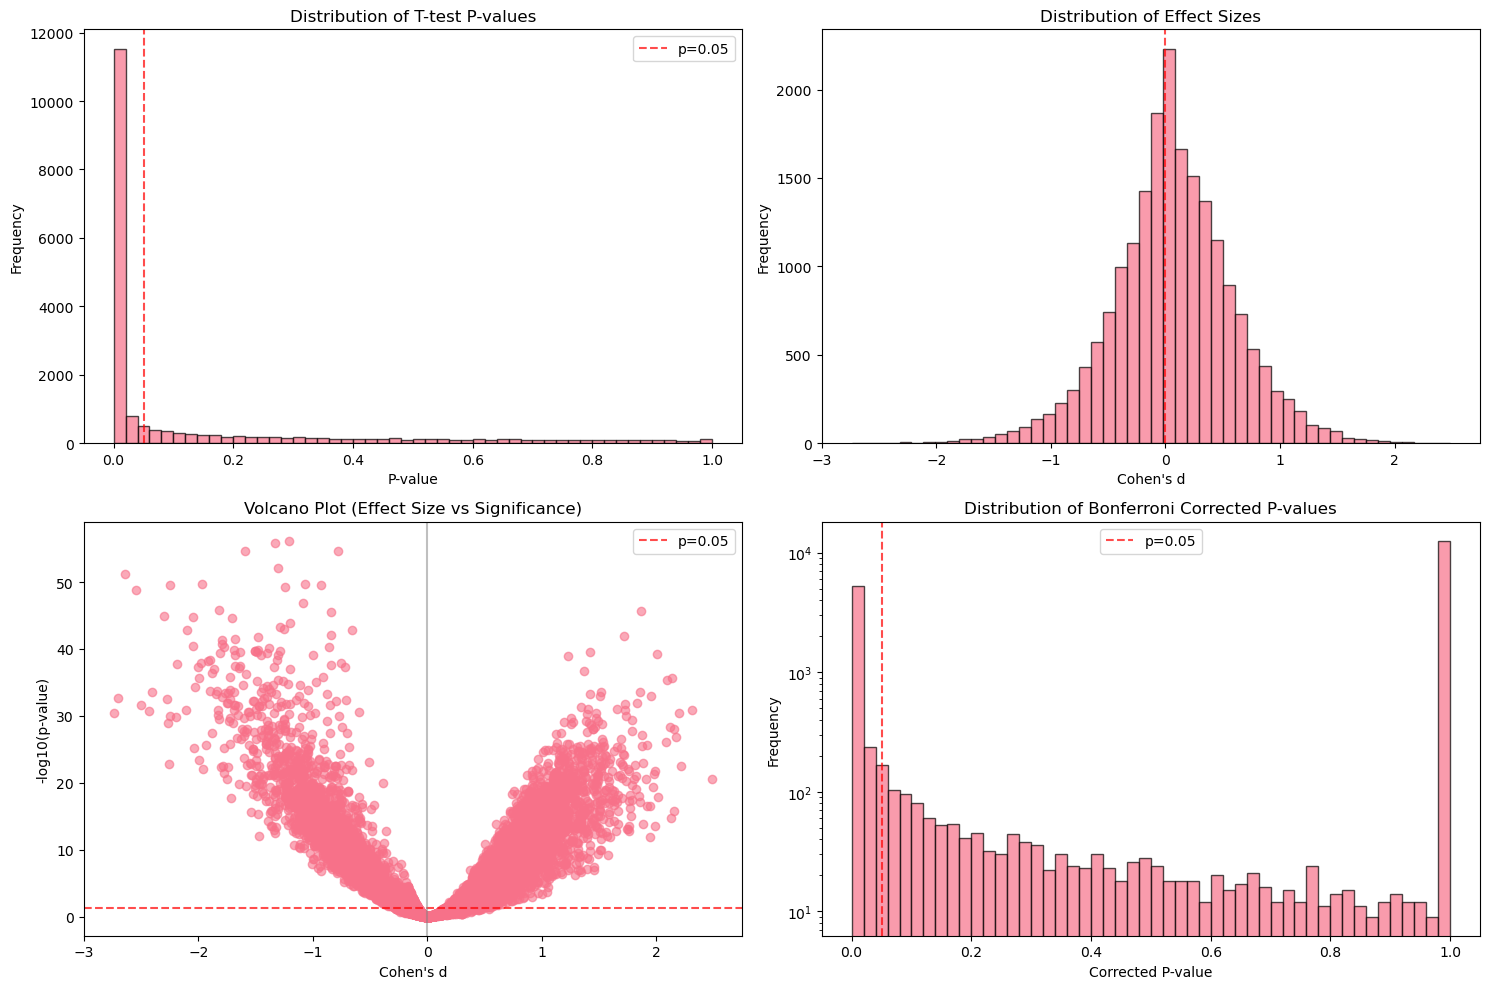

In [6]:
# Statistical T-tests for Group Differences (training data only)
# T-tests and Cohen’s d are scale-invariant.
# Scaled training features are used here for consistency with other
# feature-selection methods and to ensure all statistics operate
# on the same feature representation.

print("Statistical T-tests for Group Differences")
print("=" * 50)

ttest_results = []

# Split TRAINING data by TNBC status
tnbc_group = X_trainScaled_df[y_train == 1]
non_tnbc_group = X_trainScaled_df[y_train == 0]

print(f"TNBC group size (train): {len(tnbc_group)}")
print(f"Non-TNBC group size (train): {len(non_tnbc_group)}")

for gene in X_trainScaled_df.columns:
    try:
        # Get expression values for each group
        tnbc_expr = tnbc_group[gene].dropna()
        non_tnbc_expr = non_tnbc_group[gene].dropna()

        # Skip if insufficient data
        if len(tnbc_expr) < 5 or len(non_tnbc_expr) < 5:
            continue

        # Perform independent t-test
        t_stat, p_value = stats.ttest_ind(
            tnbc_expr,
            non_tnbc_expr,
            equal_var=False  # safer default
        )

        # Calculate effect size (Cohen's d)
        pooled_std = np.sqrt(
            ((len(tnbc_expr) - 1) * tnbc_expr.var() +
             (len(non_tnbc_expr) - 1) * non_tnbc_expr.var()) /
            (len(tnbc_expr) + len(non_tnbc_expr) - 2)
        )

        cohens_d = (
            (tnbc_expr.mean() - non_tnbc_expr.mean()) / pooled_std
            if pooled_std > 0 else 0
        )

        ttest_results.append({
            'gene': gene,
            't_statistic': t_stat,
            'p_value': p_value,
            'cohens_d': cohens_d,
            'abs_cohens_d': abs(cohens_d),
            'tnbc_mean': tnbc_expr.mean(),
            'non_tnbc_mean': non_tnbc_expr.mean(),
            'fold_change': (
                tnbc_expr.mean() / non_tnbc_expr.mean()
                if non_tnbc_expr.mean() != 0 else np.inf
            )
        })

    except Exception as e:
        print(f"Error in t-test for {gene}: {e}")

# Convert to DataFrame and sort by significance and effect size
ttest_df = pd.DataFrame(ttest_results)
ttest_df = ttest_df.sort_values(['p_value', 'abs_cohens_d'], ascending=[True, False])

print(f"\nTop 20 genes by t-test significance and effect size:")
print(ttest_df.head(20))

# Apply multiple testing correction (Bonferroni)
from statsmodels.stats.multitest import multipletests
_, p_corrected, _, _ = multipletests(ttest_df['p_value'], method='bonferroni')
ttest_df['p_corrected'] = p_corrected

# Filter genes with significant differences after correction
significant_ttest_genes = ttest_df[(ttest_df['p_corrected'] < 0.05) & (ttest_df['abs_cohens_d'] > 0.3)]
print(f"\nGenes with significant differences after Bonferroni correction (p<0.05, |d|>0.3): {len(significant_ttest_genes)}")

# Visualize results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# P-value distribution
ax1.hist(ttest_df['p_value'], bins=50, alpha=0.7, edgecolor='black')
ax1.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, label='p=0.05')
ax1.set_xlabel('P-value')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of T-test P-values')
ax1.legend()

# Effect size distribution
ax2.hist(ttest_df['cohens_d'], bins=50, alpha=0.7, edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel("Cohen's d")
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Effect Sizes')

# Volcano plot
ax3.scatter(ttest_df['cohens_d'], -np.log10(ttest_df['p_value']), alpha=0.6)
ax3.axhline(y=-np.log10(0.05), color='red', linestyle='--', alpha=0.7, label='p=0.05')
ax3.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
ax3.set_xlabel("Cohen's d")
ax3.set_ylabel('-log10(p-value)')
ax3.set_title('Volcano Plot (Effect Size vs Significance)')
ax3.legend()

# Corrected p-values
ax4.hist(ttest_df['p_corrected'], bins=50, alpha=0.7, edgecolor='black')
ax4.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, label='p=0.05')
ax4.set_xlabel('Corrected P-value')
ax4.set_ylabel('Frequency')
ax4.set_title('Distribution of Bonferroni Corrected P-values')
ax4.legend()
ax4.set_yscale('log')

plt.tight_layout()
plt.show()

Mutual Information Analysis
Calculating mutual information on scaled training data...

Top 20 genes by mutual information:
         gene  mutual_info
1931     ESR1     0.195699
3392    GATA3     0.185788
4430     MLPH     0.185502
1255     CA12     0.181602
6074    FOXA1     0.179437
726     FOXC1     0.178750
3632   TBC1D9     0.178418
10277    TFF1     0.178318
6871    C5AR2     0.177127
10275    TFF3     0.172383
7781     TTC6     0.169827
14977   SRARP     0.167381
13254    AGR3     0.167224
15753   THSD4     0.163869
2204     XBP1     0.163742
3297     AGR2     0.163078
15976    FZD9     0.162966
5504    SPDEF     0.162806
709    MCF2L2     0.162351
4926   BCL11A     0.160311


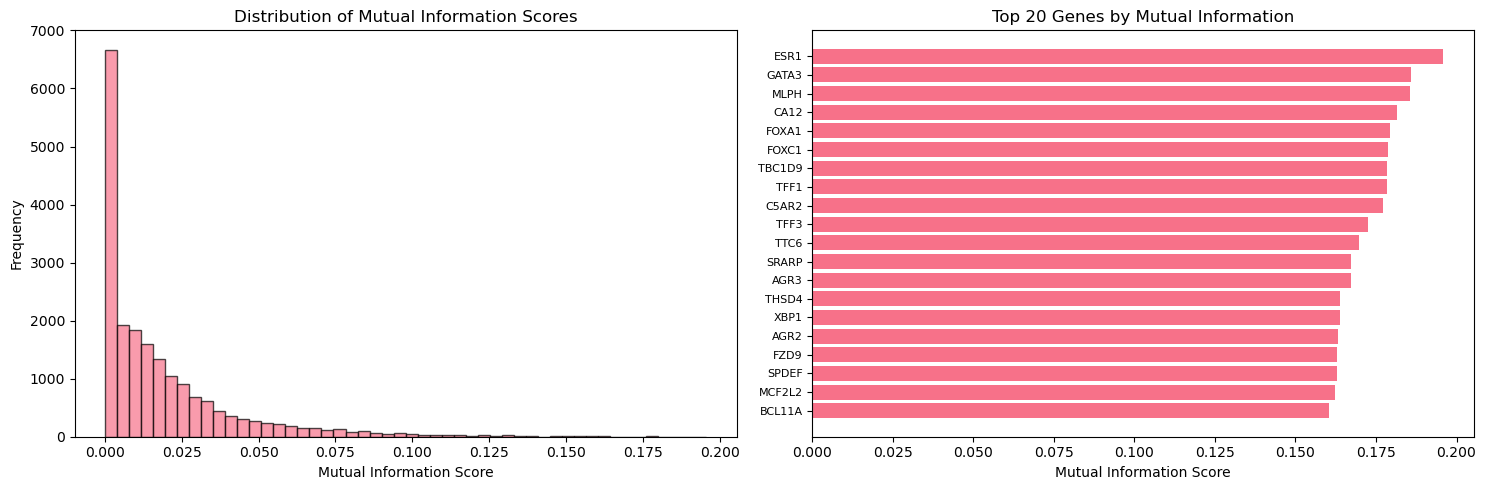


Genes with high mutual information (top 10%): 1994


In [7]:
# Mutual Information Analysis (training data only)
# Mutual information is sensitive to feature scale.
# Scaled training features are used here to ensure fair
# comparison across genes and to avoid variance-driven bias.

print("Mutual Information Analysis")
print("=" * 50)

print("Calculating mutual information on scaled training data...")

mi_scores = mutual_info_classif(
    X_trainScaled_df,
    y_train,
    random_state=42
)

# Create DataFrame with mutual information scores
mi_df = pd.DataFrame({
    'gene': X_trainScaled_df.columns,
    'mutual_info': mi_scores
}).sort_values('mutual_info', ascending=False)

print(f"\nTop 20 genes by mutual information:")
print(mi_df.head(20))



# Visualize mutual information distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(mi_df['mutual_info'], bins=50, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Mutual Information Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Mutual Information Scores')

# Top genes bar plot
top_mi_genes = mi_df.head(20)
ax2.barh(range(len(top_mi_genes)), top_mi_genes['mutual_info'])
ax2.set_yticks(range(len(top_mi_genes)))
ax2.set_yticklabels(top_mi_genes['gene'], fontsize=8)
ax2.set_xlabel('Mutual Information Score')
ax2.set_title('Top 20 Genes by Mutual Information')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# Filter genes with high mutual information
high_mi_genes = mi_df[mi_df['mutual_info'] > mi_df['mutual_info'].quantile(0.9)]
print(f"\nGenes with high mutual information (top 10%): {len(high_mi_genes)}")

# Variance score

In [8]:
#This variance reflects relative dispersion after preprocessing 
# and is used as a weak heuristic signal rather than a primary filtering criterion.
variance_series = X_trainScaled_df.var()

# Combining Statistical Methods for Final Gene Selection.

\Final Gene Selection
Combining results from all statistical analyses...

Total genes analyzed: 19938
Genes with statistical significance: 12431

Top 30 genes by composite statistical score:
          gene  composite_score  correlation_score  ttest_score  mi_score  \
1931      ESR1         0.981368           0.978299     0.962265  1.000000   
4430      MLPH         0.976957           0.991459     0.984925  0.947895   
6074     FOXA1         0.975072           1.000000     1.000000  0.916905   
13254     AGR3         0.920707           0.957821     0.928291  0.854499   
7781      TTC6         0.915972           0.947072     0.911041  0.867800   
10275     TFF3         0.903547           0.926489     0.879049  0.880859   
3392     GATA3         0.899233           0.894061     0.831171  0.949358   
3297      AGR2         0.893957           0.932435     0.888157  0.833312   
10277     TFF1         0.891727           0.899296     0.838705  0.911187   
1255      CA12         0.875009        

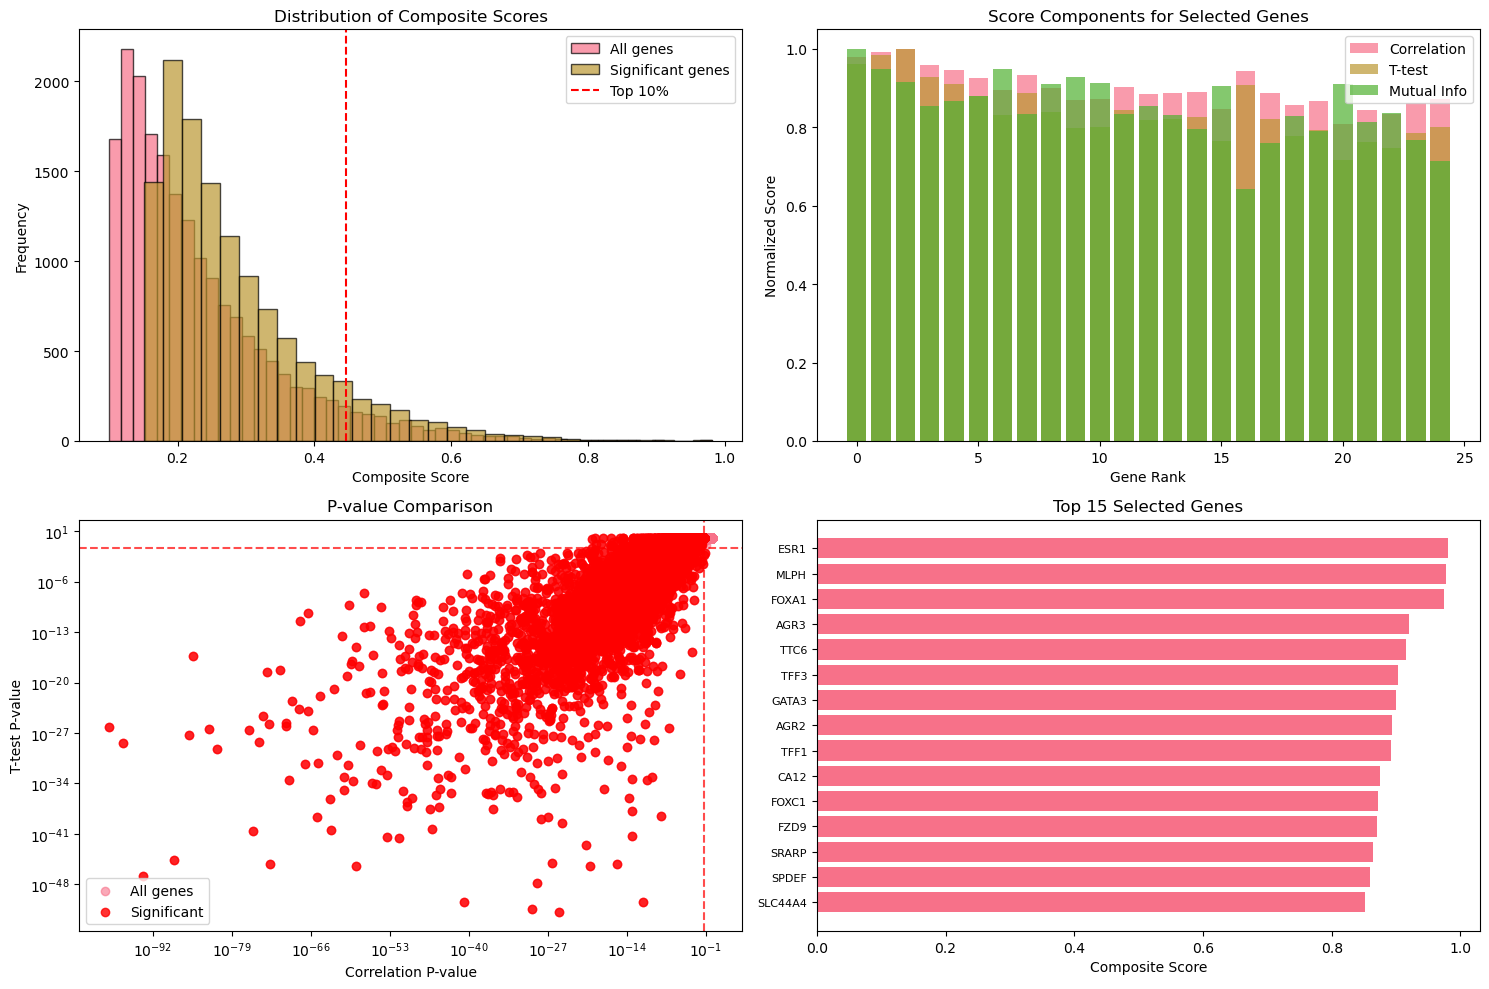


Statistical feature selection completed!
Selected 156 genes using comprehensive statistical analysis.


In [ ]:
# Scores are combined heuristically (not optimized) to integrate
# complementary statistical perspectives (correlation, effect size,
# mutual information, and variance). This ranking is used as a
# qualitative selector, not as a hypothesis test.

print("\nFinal Gene Selection")
print("=" * 60)
print("Combining results from all statistical analyses...")

# Create a comprehensive scoring system
final_scores = []

for gene in X_train.columns:
    score_dict = {'gene': gene}

    # Correlation score (normalized)
    corr_info = corr_df[corr_df['gene'] == gene]
    if not corr_info.empty:
        score_dict['correlation_score'] = corr_info['abs_correlation'].iloc[0]
        score_dict['correlation_p'] = corr_info['p_value'].iloc[0]
    else:
        score_dict['correlation_score'] = 0
        score_dict['correlation_p'] = 1

    # T-test score
    ttest_info = ttest_df[ttest_df['gene'] == gene]
    if not ttest_info.empty:
        score_dict['ttest_score'] = ttest_info['abs_cohens_d'].iloc[0]
        score_dict['ttest_p'] = ttest_info['p_corrected'].iloc[0]
        score_dict['fold_change'] = ttest_info['fold_change'].iloc[0]
    else:
        score_dict['ttest_score'] = 0
        score_dict['ttest_p'] = 1
        score_dict['fold_change'] = 1

    # Mutual information score
    mi_info = mi_df[mi_df['gene'] == gene]
    if not mi_info.empty:
        score_dict['mi_score'] = mi_info['mutual_info'].iloc[0]
    else:
        score_dict['mi_score'] = 0

    score_dict['variance_score'] = variance_series.get(gene, 0)

    final_scores.append(score_dict)

# Convert to DataFrame
final_df = pd.DataFrame(final_scores)

# Normalize scores to 0-1 range for fair combination
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

score_columns = ['correlation_score', 'ttest_score', 'mi_score', 'variance_score']
final_df[score_columns] = scaler.fit_transform(final_df[score_columns])

# Create composite score with weights
weights = {
    'correlation_score': 0.25,
    'ttest_score': 0.35,      # Higher weight for effect size
    'mi_score': 0.30,         # Higher weight for mutual information
    'variance_score': 0.10     # Lower weight for variance
}

final_df['composite_score'] = sum(final_df[col] * weights[col] for col in score_columns)

# Add significance filter
final_df['is_significant'] = (final_df['correlation_p'] < 0.05) | (final_df['ttest_p'] < 0.05)

# Sort by composite score and filter for significance
significant_genes = final_df[final_df['is_significant']].sort_values('composite_score', ascending=False)

print(f"\nTotal genes analyzed: {len(final_df)}")
print(f"Genes with statistical significance: {len(significant_genes)}")
print(f"\nTop 30 genes by composite statistical score:")
print(significant_genes[['gene', 'composite_score', 'correlation_score', 'ttest_score', 'mi_score', 'correlation_p', 'ttest_p']].head(30))

# Select final set of genes
# Determine maximum number of features based on n/p > 5 heuristic
n_train = len(y_train)
max_features = n_train // 5

# Select top-ranked features up to this limit
targetGenes = significant_genes.head(max_features)['gene'].tolist()

print(f"\n" + "="*60)
print(f"FINAL SELECTED GENES ({len(targetGenes)}):")
print("="*60)
for i, gene in enumerate(targetGenes, 1):
    gene_info = significant_genes[significant_genes['gene'] == gene].iloc[0]
    print(f"{i:2d}. {gene:<15} (Score: {gene_info['composite_score']:.3f}, "
          f"Corr: {gene_info['correlation_score']:.3f}, "
          f"Effect: {gene_info['ttest_score']:.3f}, "
          f"MI: {gene_info['mi_score']:.3f})")

# Visualize final selection
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Composite score distribution
ax1.hist(final_df['composite_score'], bins=50, alpha=0.7, edgecolor='black', label='All genes')
ax1.hist(significant_genes['composite_score'], bins=30, alpha=0.7, edgecolor='black', label='Significant genes')
ax1.axvline(x=significant_genes['composite_score'].quantile(0.9), color='red', linestyle='--', label='Top 10%')
ax1.set_xlabel('Composite Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Composite Scores')
ax1.legend()

# Score components for selected genes
selected_gene_scores = significant_genes.head(25)
ax2.bar(range(len(selected_gene_scores)), selected_gene_scores['correlation_score'], alpha=0.7, label='Correlation')
ax2.bar(range(len(selected_gene_scores)), selected_gene_scores['ttest_score'], alpha=0.7, label='T-test')
ax2.bar(range(len(selected_gene_scores)), selected_gene_scores['mi_score'], alpha=0.7, label='Mutual Info')
ax2.set_xlabel('Gene Rank')
ax2.set_ylabel('Normalized Score')
ax2.set_title('Score Components for Selected Genes')
ax2.legend()

# P-value comparison
ax3.scatter(final_df['correlation_p'], final_df['ttest_p'], alpha=0.6, label='All genes')
ax3.scatter(significant_genes['correlation_p'], significant_genes['ttest_p'], alpha=0.8, color='red', label='Significant')
ax3.axhline(y=0.05, color='red', linestyle='--', alpha=0.7)
ax3.axvline(x=0.05, color='red', linestyle='--', alpha=0.7)
ax3.set_xlabel('Correlation P-value')
ax3.set_ylabel('T-test P-value')
ax3.set_title('P-value Comparison')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.legend()

# Top genes composite scores
top_genes_plot = significant_genes.head(15)
ax4.barh(range(len(top_genes_plot)), top_genes_plot['composite_score'])
ax4.set_yticks(range(len(top_genes_plot)))
ax4.set_yticklabels(top_genes_plot['gene'], fontsize=8)
ax4.set_xlabel('Composite Score')
ax4.set_title('Top 15 Selected Genes')
ax4.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nStatistical feature selection completed!")
print(f"Selected {len(targetGenes)} genes using comprehensive statistical analysis.")

# Send dataframe to a csv

In [10]:
# Create Final Dataset with Selected Genes (from preprocessed data)
print("Creating Final Dataset")
print("=" * 50)

df[targetGenes+constTargetAndMetadata].to_csv(f'../Data/interim/patient_genes_{variant}.csv', index=False)

print("Dataset written");

Creating Final Dataset
Dataset written


In [11]:
# Sanity checks
print(f"Final dataset shape: {df[targetGenes+constTargetAndMetadata].shape}")
print(f"Total samples: {len(df[targetGenes+constTargetAndMetadata])}")
print(f"Total features: {len(targetGenes)}")
print(f"TNBC distribution: {df['tnbc'].value_counts().to_dict()}")
print(f"Missing values: {df[targetGenes+constTargetAndMetadata].isnull().sum().sum()}")

Final dataset shape: (977, 158)
Total samples: 977
Total features: 156
TNBC distribution: {False: 862, True: 115}
Missing values: 0
